# A faster photometric model

Currently, LinearNDInterpolator in the photometry predictor is MASSIVELY slowing down the code. Can I find something faster?

## Imports

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator, RegularGridInterpolator

from gaianir_open_clusters.config import RESULTS_DIRECTORY

In [25]:
photometry = pd.read_parquet(RESULTS_DIRECTORY / "photometry.parquet")

In [26]:
photometry

,teff,logg,feh,N,N_R,N_J,N_H,N_K
0,2000.0,0.0,0.0,-35.435861,-33.905702,-35.659084,-36.032519,-36.552955
1,2000.0,0.5,0.0,-35.530915,-34.029892,-35.692901,-36.123730,-36.683483
2,2000.0,1.0,0.0,-35.571691,-34.036785,-35.651342,-36.190725,-36.765165
3,2000.0,1.5,0.0,-35.660148,-34.142300,-35.744687,-36.281816,-36.842217
4,2000.0,2.0,0.0,-35.667375,-34.067697,-35.727105,-36.302954,-36.879707
...,...,...,...,...,...,...,...,...
4059,50000.0,5.0,-1.0,-42.825431,-42.958099,-42.749879,-42.654441,-42.553503
4060,50000.0,5.0,-0.5,-42.838151,-42.971971,-42.762324,-42.665273,-42.562645
4061,50000.0,5.0,0.0,-42.852646,-42.988220,-42.776435,-42.676717,-42.571848
4062,50000.0,5.0,0.2,-42.859726,-42.996195,-42.783221,-42.682337,-42.576249


## A quick benchmark

In [44]:
res = 100

x = np.linspace(0, 1, num=res)
y = np.linspace(0, 1, num=res)

X, Y = np.meshgrid(x, y)
Z = X**2 + Y**1.5

X_flat = X.flatten()
Y_flat = Y.flatten()
Z_flat = Z.flatten()

In [29]:
rng = np.random.default_rng(seed=42)

query_points = rng.uniform(size=(10000, 2))

In [28]:
linear_interp = LinearNDInterpolator(np.vstack((X_flat, Y_flat)).T, Z_flat)
grid_interp = RegularGridInterpolator((x, y), Z)

In [30]:
%%timeit
linear_interp(query_points)

18 ms ± 841 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [31]:
%%timeit
grid_interp(query_points)

819 μs ± 10.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [48]:
%%timeit
grid_interp(query_points, method="nearest")

867 μs ± 18.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


well that fucking settles it doesn't it

## Making a grid interpolator

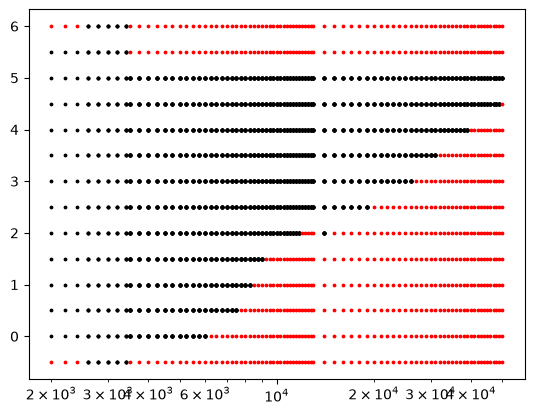

In [56]:
all_temperatures = photometry['teff'].unique()
all_log_g = photometry['logg'].unique()

plt.scatter(photometry['teff'], photometry['logg'], s=3, c="k")
plt.xscale("log")

for log_g in all_log_g:
    sample = photometry.query(f"logg=={log_g}")
    missing_temps = all_temperatures[np.isin(all_temperatures, sample['teff'], invert=True)]
    plt.scatter(missing_temps, np.full_like(missing_temps, log_g), c="r", s=3)

Some of these are missing at certain Fe/H - aaaaa

In [253]:
bands = ["N", "N_R", "N_J", "N_H", "N_K"]

photometry_sample = photometry.sort_values(["feh", "logg", "teff"]).reset_index(
    drop=True
)

# Add some additional points where we assume solar metallicity so that no metallicity
# has NaN values. Not ideal, but I couldn't find more atmo models
photometry_sample_zero = photometry_sample.query("feh==0.0")
photometry_sample_low = photometry_sample_zero.copy()
photometry_sample_low["feh"] = -2.6
photometry_sample_high = photometry_sample_zero.copy()
photometry_sample_high["feh"] = 0.6
photometry_sample = pd.concat(
    [photometry_sample_low, photometry_sample, photometry_sample_high]
).reset_index(drop=True)

all_temperatures = np.unique(photometry_sample["teff"])
all_log_g = np.unique(photometry_sample["logg"])
all_feh = np.unique(photometry_sample["feh"])

temp_grid, log_g_grid, feh_grid = np.meshgrid(
    all_temperatures, all_log_g, all_feh, indexing="ij"
)

grid_2d = np.vstack([x.flatten() for x in (temp_grid, log_g_grid, feh_grid)]).T

# make a simple triangulation-based interpolator
x = photometry_sample[["teff", "logg", "feh"]].to_numpy()
y_big = photometry_sample[bands]

linear_interp = LinearNDInterpolator(x, y_big)

# Use it to get missing values
photometry_grid = np.zeros((grid_2d.shape[0], len(bands)))
photometry_grid = linear_interp(grid_2d).reshape(list(temp_grid.shape) + [len(bands)])

# Then, set any still-missing values to zero
is_nan = np.invert(np.isfinite(photometry_grid))
photometry_grid[is_nan] = 0.0

grid_interp = RegularGridInterpolator(
    (all_temperatures, all_log_g, all_feh), photometry_grid
)

Test them:

In [254]:
%%timeit
linear_interp(x)

442 ms ± 7.11 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [255]:
%%timeit
grid_interp(x)

939 μs ± 9.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [256]:
interpolated = grid_interp(x)

In [257]:
interpolated_2 = linear_interp(x)

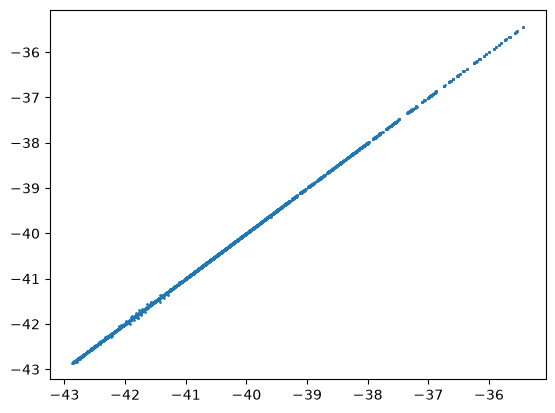

In [258]:
plt.scatter(y_big['N'], interpolated[:, 0], s=1)
# plt.scatter(y_big['N'], interpolated_2[:, 0], s=1)

Check that the scheme can handle missing metallicities:

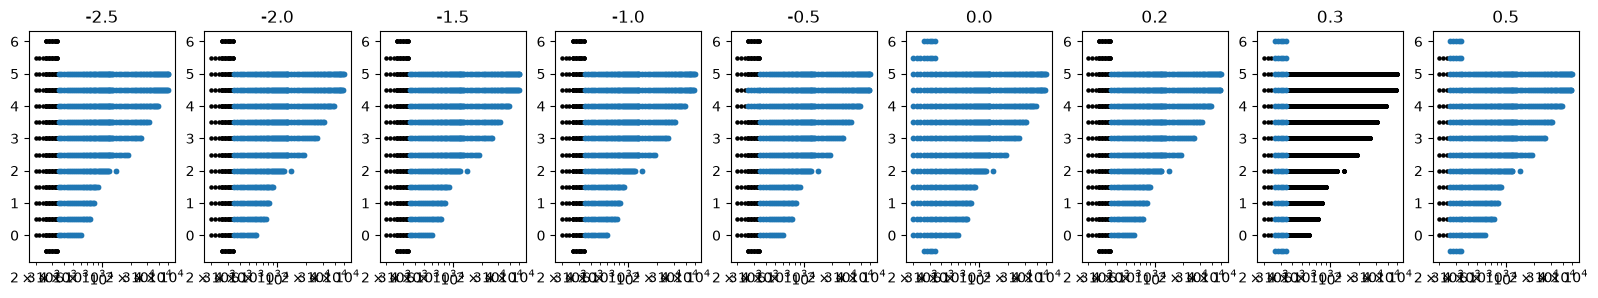

In [260]:
all_feh = photometry['feh'].unique()

fig, ax = plt.subplots(ncols=len(all_feh), figsize=(20, 3))


for an_ax, feh in zip(ax, photometry['feh'].unique()):
    sample = photometry.query(f"feh=={feh}")
    an_ax.scatter(photometry['teff'], photometry['logg'], s=5, c="k")
    an_ax.scatter(sample['teff'], sample['logg'], s=10)
    an_ax.set(title=feh, xscale="log")


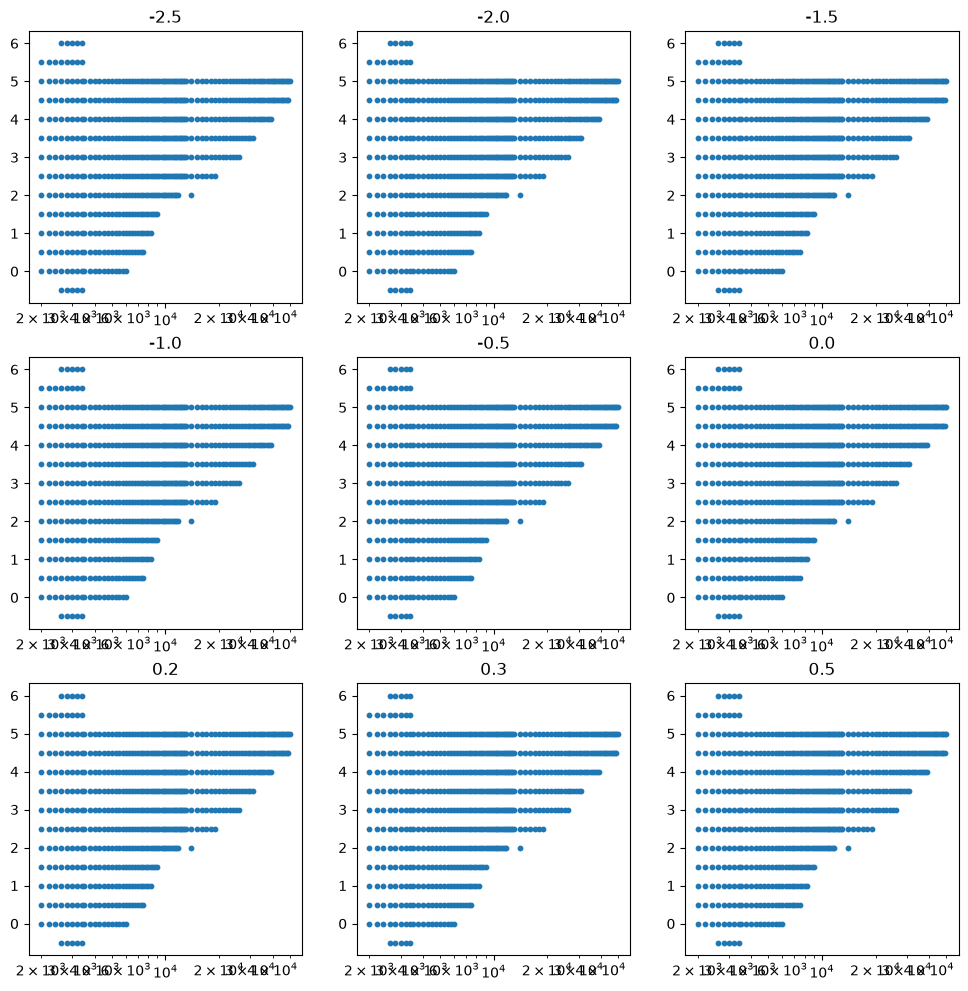

In [261]:
all_feh = photometry["feh"].unique()

fig, ax = plt.subplots(ncols=3, nrows=3, figsize=(12, 12))
ax = ax.flatten()

possible_values = photometry[["teff", "logg"]].drop_duplicates(["teff", "logg"])


for an_ax, feh in zip(ax, photometry["feh"].unique()):
    sample = photometry.query(f"feh=={feh}")
    an_ax.scatter(possible_values["teff"], possible_values["logg"], s=5, c="k")

    possible_values["feh"] = feh
    interp = linear_interp(possible_values[["teff", "logg", "feh"]].to_numpy())
    not_nan = np.isfinite(interp[:, 0])
    an_ax.scatter(
        possible_values.loc[not_nan, "teff"], possible_values.loc[not_nan, "logg"], s=10
    )
    an_ax.set(title=feh, xscale="log")


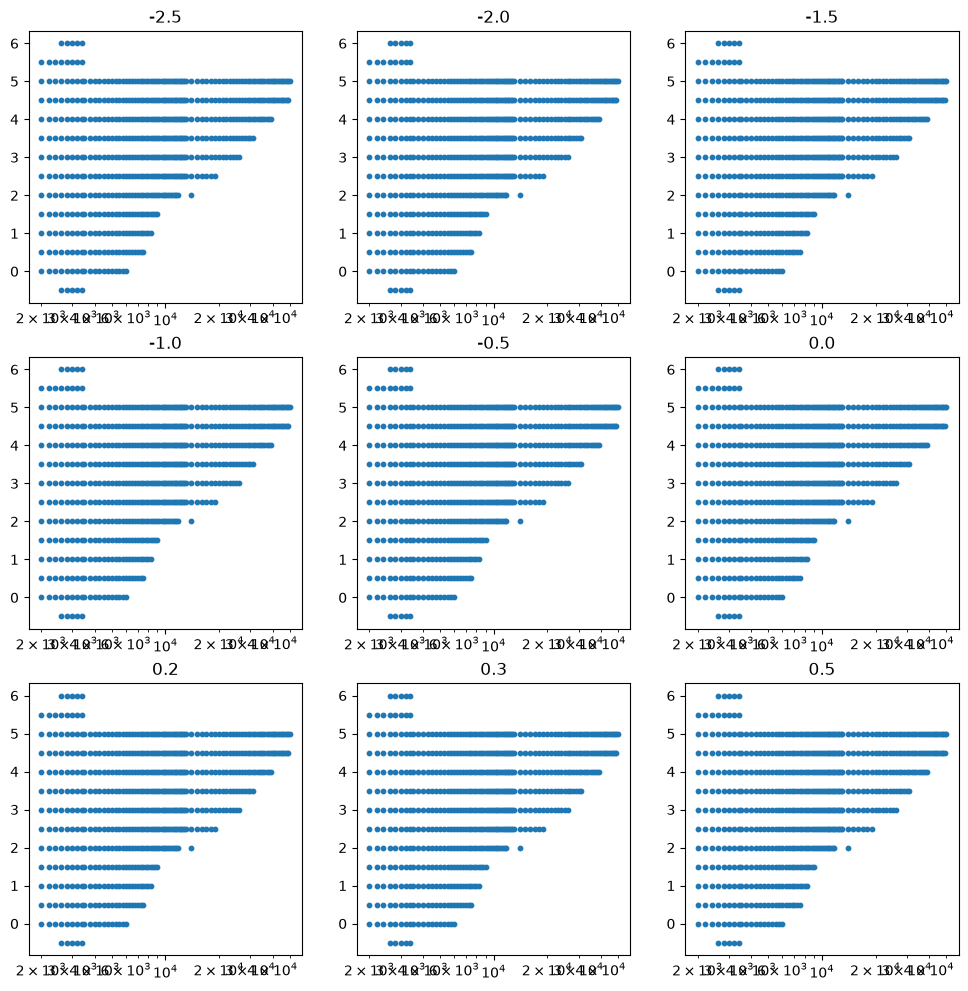

In [262]:
all_feh = photometry["feh"].unique()

fig, ax = plt.subplots(ncols=3, nrows=3, figsize=(12, 12))
ax = ax.flatten()

possible_values = photometry[["teff", "logg"]].drop_duplicates(["teff", "logg"])


for an_ax, feh in zip(ax, photometry["feh"].unique()):
    sample = photometry.query(f"feh=={feh}")
    an_ax.scatter(possible_values["teff"], possible_values["logg"], s=5, c="k")

    possible_values["feh"] = feh
    interp = grid_interp(possible_values[["teff", "logg", "feh"]].to_numpy())
    not_nan = np.isfinite(interp[:, 0])
    an_ax.scatter(
        possible_values.loc[not_nan, "teff"], possible_values.loc[not_nan, "logg"], s=10
    )
    an_ax.set(title=feh, xscale="log")
